# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbhutto256/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The output of this notebook is a **review queue**, not an automatic content-editing system. Each row receives three things: a measured decline-risk score from the client-grouped Logistic Regression model, a simple value signal based on first-half impressions, and **reason codes** that explain which observable pre-decision signals made the page worth reviewing.

I use four practical action archetypes:

| Archetype | When I use it | Suggested human action | Typical reason codes |
|---|---|---|---|
| **CTR opportunity** | The page still earns impressions/visibility but CTR is weak relative to the training distribution. | Review title, description/snippet fit, intent match, and SERP presentation. | `LOW_CTR`, `HIGH_IMPRESSIONS` |
| **Ranking-depth opportunity** | The page has meaningful impressions but average position is relatively weak. | Review content depth, internal linking, topical coverage, and competing pages before changing copy. | `WEAK_POSITION`, `HIGH_IMPRESSIONS` |
| **Refresh candidate** | The model ranks the page as higher decline risk and its activity/engagement signals look weaker while it still has material visibility. | Human checks whether the page is stale, outdated, cannibalized, or losing relevance; refresh only if the content evidence supports it. | `LOW_ACTIVE_DAYS`, `LOW_CTR`, `HIGH_IMPRESSIONS` |
| **Monitor / low-evidence** | Traffic opportunity is small or the signals are mixed. | Do not rush into an edit. Recheck later or gather more context first. | `LOW_IMPRESSIONS`, `MIXED_SIGNAL` |

The **decay/refresh insight is a hypothesis, not a causal rule**. The research paper observed that growing pages were younger on average than declining pages. My model does not contain page age and cannot prove that freshness caused decline. I therefore use “refresh candidate” only as a human-review archetype when the measured risk is high and the current pre-decision performance signals justify inspection.

### Ranking logic

For the held-out client set, I compute:

- `risk_score` = grouped-model probability for the defined decline proxy.
- `value_score` = percentile rank of `first_half_impressions` within the held-out queue.
- `priority_score` = 70% risk + 30% value. This intentionally favors measured risk while preventing tiny pages from dominating the top of the action list.
- `reason_codes` = transparent flags relative to **training-only** quartiles.
- `recommended_action` = rule-based mapping from those reason codes to one of the four archetypes above.

This is deliberately simple. A more complex optimizer would be harder to defend and is unnecessary for a non-production playbook.


In [1]:
# Build the honest grouped model and turn the held-out output into a ranked action queue.
# Add HF_TOKEN in Colab Secrets. The token is never printed or written to disk.

%pip -q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib

import os, getpass, json
from pathlib import Path
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass("Enter Hugging Face READ token (hidden): ")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
DAILY = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"

FEATURE_COLS = [
    "first_half_impressions",
    "first_half_clicks",
    "first_half_avg_position",
    "first_half_active_days",
    "first_half_ctr_pct",
]
TARGET = "decline_proxy"
GROUP = "client_hash_id"

feature_sql = f"""
WITH daily AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        COALESCE(gsc_impressions, 0) AS gsc_impressions,
        COALESCE(gsc_clicks, 0) AS gsc_clicks,
        NULLIF(gsc_avg_position, 0) AS gsc_avg_position
    FROM {DAILY}
    WHERE gsc_data_available IS TRUE
),
agg AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                 THEN gsc_impressions ELSE 0 END) AS first_half_impressions,
        SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                 THEN gsc_clicks ELSE 0 END) AS first_half_clicks,
        AVG(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                 THEN gsc_avg_position END) AS first_half_avg_position,
        COUNT(DISTINCT CASE
            WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
             AND gsc_impressions > 0 THEN report_date END
        ) AS first_half_active_days,
        SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
                 THEN gsc_impressions ELSE 0 END) AS second_half_impressions
    FROM daily
    GROUP BY 1,2
)
SELECT
    client_hash_id,
    content_hash_id,
    first_half_impressions,
    first_half_clicks,
    first_half_avg_position,
    first_half_active_days,
    100.0 * first_half_clicks / NULLIF(first_half_impressions,0) AS first_half_ctr_pct,
    CASE
        WHEN first_half_impressions > 0
         AND second_half_impressions < 0.80 * first_half_impressions
        THEN 1 ELSE 0
    END AS decline_proxy
FROM agg
WHERE first_half_impressions > 0
"""

model_df = con.sql(feature_sql).df()
X = model_df[FEATURE_COLS]
y = model_df[TARGET].astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=model_df[GROUP]))
train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

assert set(train_df[GROUP]).isdisjoint(set(test_df[GROUP]))

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])
model.fit(train_df[FEATURE_COLS], train_df[TARGET].astype(int))

test_df["risk_score"] = model.predict_proba(test_df[FEATURE_COLS])[:,1]

# Training-only thresholds keep the action rules independent of the held-out queue.
cut = {
    "ctr_q25": train_df["first_half_ctr_pct"].quantile(0.25),
    "position_q75": train_df["first_half_avg_position"].quantile(0.75),
    "active_q25": train_df["first_half_active_days"].quantile(0.25),
    "impressions_q25": train_df["first_half_impressions"].quantile(0.25),
    "impressions_q75": train_df["first_half_impressions"].quantile(0.75),
}

# Value is relative within the held-out review population; it is not monetary value.
test_df["value_score"] = test_df["first_half_impressions"].rank(pct=True, method="average")
test_df["priority_score"] = 0.70 * test_df["risk_score"] + 0.30 * test_df["value_score"]

def reason_codes(row):
    reasons = []
    if row["first_half_ctr_pct"] <= cut["ctr_q25"]:
        reasons.append("LOW_CTR")
    if row["first_half_avg_position"] >= cut["position_q75"]:
        reasons.append("WEAK_POSITION")
    if row["first_half_active_days"] <= cut["active_q25"]:
        reasons.append("LOW_ACTIVE_DAYS")
    if row["first_half_impressions"] >= cut["impressions_q75"]:
        reasons.append("HIGH_IMPRESSIONS")
    if row["first_half_impressions"] <= cut["impressions_q25"]:
        reasons.append("LOW_IMPRESSIONS")
    if not reasons:
        reasons.append("MIXED_SIGNAL")
    return reasons

def map_action(row):
    reasons = set(row["reason_codes_list"])
    # Keep low-opportunity rows out of expensive work unless risk is extremely high.
    if "LOW_IMPRESSIONS" in reasons and row["risk_score"] < 0.80:
        return "Monitor / low-evidence"
    if "HIGH_IMPRESSIONS" in reasons and "LOW_CTR" in reasons:
        return "CTR opportunity"
    if "HIGH_IMPRESSIONS" in reasons and "WEAK_POSITION" in reasons:
        return "Ranking-depth opportunity"
    if row["risk_score"] >= 0.65 and ("LOW_ACTIVE_DAYS" in reasons or "LOW_CTR" in reasons):
        return "Refresh candidate"
    return "Monitor / low-evidence"

def effort_for(action):
    return {
        "CTR opportunity": "Low",
        "Ranking-depth opportunity": "Medium",
        "Refresh candidate": "Medium–High",
        "Monitor / low-evidence": "Low",
    }[action]

def next_step_for(action):
    return {
        "CTR opportunity": "Inspect query/intent fit and SERP presentation; draft title/snippet changes only after review.",
        "Ranking-depth opportunity": "Inspect competing results, topical gaps and internal links before proposing content changes.",
        "Refresh candidate": "Check freshness, factual drift, cannibalization and current usefulness; refresh only if evidence supports it.",
        "Monitor / low-evidence": "Defer edit; collect another observation window or stronger page-level context first.",
    }[action]

test_df["reason_codes_list"] = test_df.apply(reason_codes, axis=1)
test_df["reason_codes"] = test_df["reason_codes_list"].apply(lambda x: "|".join(x))
test_df["recommended_action"] = test_df.apply(map_action, axis=1)
test_df["estimated_effort"] = test_df["recommended_action"].map(effort_for)
test_df["human_next_step"] = test_df["recommended_action"].map(next_step_for)

queue = (
    test_df
    .sort_values(["priority_score", "risk_score"], ascending=False)
    .reset_index(drop=True)
)
queue["rank"] = np.arange(1, len(queue)+1)

queue_cols = [
    "rank", "client_hash_id", "content_hash_id",
    "risk_score", "value_score", "priority_score",
    "recommended_action", "reason_codes", "estimated_effort", "human_next_step",
    "first_half_impressions", "first_half_clicks", "first_half_avg_position",
    "first_half_active_days", "first_half_ctr_pct",
]
queue = queue[queue_cols]

print(f"Held-out review rows: {len(queue):,}")
print(f"Held-out clients: {test_df[GROUP].nunique():,}")
print("\nTop 15 ranked review candidates:")
display(queue.head(15).round({"risk_score":3,"value_score":3,"priority_score":3,"first_half_ctr_pct":2,"first_half_avg_position":2}))

print("\nAction mix:")
display(queue["recommended_action"].value_counts().rename("rows").to_frame())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Held-out review rows: 13,210
Held-out clients: 9

Top 15 ranked review candidates:


,rank,client_hash_id,content_hash_id,risk_score,value_score,priority_score,recommended_action,reason_codes,estimated_effort,human_next_step,first_half_impressions,first_half_clicks,first_half_avg_position,first_half_active_days,first_half_ctr_pct
0,1,client_e5c2aa26a8598242,content_39457d17e716086c,0.889,1.000,0.922,Ranking-depth opportunity,WEAK_POSITION|HIGH_IMPRESSIONS,Medium,"Inspect competing results, topical gaps and in...",25042.0,7.0,38.27,15,0.03
1,2,client_e5c2aa26a8598242,content_8b898761780f350c,0.724,0.998,0.806,Ranking-depth opportunity,WEAK_POSITION|HIGH_IMPRESSIONS,Medium,"Inspect competing results, topical gaps and in...",12567.0,1.0,45.08,15,0.01
2,3,client_e5c2aa26a8598242,content_d1db17521a55d9fc,0.709,0.999,0.796,Ranking-depth opportunity,WEAK_POSITION|HIGH_IMPRESSIONS,Medium,"Inspect competing results, topical gaps and in...",19059.0,19.0,30.67,15,0.10
3,4,client_c182d11e4862a37d,content_d2eb49b1f5f3fa34,0.702,0.996,0.790,CTR opportunity,LOW_CTR|HIGH_IMPRESSIONS,Low,Inspect query/intent fit and SERP presentation...,8895.0,0.0,7.34,15,0.00
4,5,client_e5c2aa26a8598242,content_9a4594adab0f2c81,0.692,0.999,0.784,Ranking-depth opportunity,WEAK_POSITION|HIGH_IMPRESSIONS,Medium,"Inspect competing results, topical gaps and in...",14995.0,11.0,34.69,15,0.07
5,6,client_e5c2aa26a8598242,content_4977e90c4d93cf9f,0.687,0.999,0.781,Monitor / low-evidence,HIGH_IMPRESSIONS,Low,Defer edit; collect another observation window...,15397.0,16.0,7.25,15,0.10
6,7,client_0fa64a184f18a4a0,content_76a6fa55e21323b3,0.680,0.985,0.772,CTR opportunity,LOW_CTR|LOW_ACTIVE_DAYS|HIGH_IMPRESSIONS,Low,Inspect query/intent fit and SERP presentation...,4962.0,0.0,8.50,7,0.00
7,8,client_e5c2aa26a8598242,content_e9512211e3076e1c,0.665,0.996,0.764,CTR opportunity,LOW_CTR|WEAK_POSITION|HIGH_IMPRESSIONS,Low,Inspect query/intent fit and SERP presentation...,9063.0,0.0,36.63,15,0.00
8,9,client_0fa64a184f18a4a0,content_fe8328ab251759cc,0.660,0.986,0.758,CTR opportunity,LOW_CTR|HIGH_IMPRESSIONS,Low,Inspect query/intent fit and SERP presentation...,5248.0,0.0,7.96,10,0.00
9,10,client_e5c2aa26a8598242,content_567d370cf1fdbd1d,0.654,0.998,0.757,Ranking-depth opportunity,WEAK_POSITION|HIGH_IMPRESSIONS,Medium,"Inspect competing results, topical gaps and in...",12318.0,8.0,38.72,15,0.06



Action mix:


,rows
recommended_action,
Monitor / low-evidence,12755
CTR opportunity,285
Ranking-depth opportunity,170


## 2. Intended use and limits

### Intended use

This playbook is for a **content/SEO analyst or editor deciding what to inspect first**. It converts a model score into an explainable review queue. The human sees the suggested action, reason codes, effort level, and the underlying first-half signals before deciding whether any edit is justified.

The queue is useful for questions such as:

- Which high-visibility pages should I inspect first?
- Is the main observed issue closer to CTR, ranking depth, or a broader refresh question?
- Which low-value pages should I defer instead of spending editorial time on immediately?

### Cost / value thinking

I do not treat every model-positive page as equally valuable. Editing has a real cost: analysis time, writing time, engineering/QA time, and the risk of harming a page that was already performing adequately. That is why the priority score combines **decline risk with current impression opportunity** and why the action map includes a “monitor / low-evidence” outcome.

A practical operating rule is:

- **High risk + high value:** review first; a justified improvement has more upside.
- **High risk + low value:** inspect cheaply; do not spend a large refresh budget without more evidence.
- **Low risk + high value:** monitor and protect; avoid unnecessary edits.
- **Low risk + low value:** lowest priority unless there is a separate business reason.

### Limits

This remains a **March 2026, non-production decision-support exercise**. The target is an observed impression-decline proxy, not a causal label. The model does not know content quality, query intent, conversions, revenue, backlinks, seasonality, indexation state, page age, competitor changes, or business priority. It therefore cannot answer *why* a page moved or guarantee that a recommended edit will improve performance.

The grouped validation design is the result I would defend for unseen-client decision-support, but one grouped split is not enough to claim broad stability. Week-6 explicitly treated stronger public claims as requiring repeated grouped and/or future-time validation. fileciteturn21file9L648-L675


In [2]:
# Cost/value summary and a small policy table for the paper.

action_summary = (
    queue.groupby("recommended_action")
    .agg(
        rows=("rank", "count"),
        median_risk=("risk_score", "median"),
        median_impressions=("first_half_impressions", "median"),
        median_priority=("priority_score", "median"),
    )
    .sort_values("median_priority", ascending=False)
)

display(action_summary.round(3))

policy = pd.DataFrame([
    ["High", "High", "Review first", "Worth analyst/editor time first"],
    ["High", "Low", "Cheap diagnostic first", "Avoid expensive rewrite without more evidence"],
    ["Low", "High", "Monitor / protect", "Unnecessary edits can destroy value"],
    ["Low", "Low", "Defer", "Lowest expected return on review time"],
], columns=["Measured risk", "Current value", "Operating decision", "Cost/value rationale"])

display(policy)


,rows,median_risk,median_impressions,median_priority
recommended_action,,,,
CTR opportunity,285,0.494,875.0,0.606
Ranking-depth opportunity,170,0.437,1992.5,0.579
Monitor / low-evidence,12755,0.515,59.0,0.495


,Measured risk,Current value,Operating decision,Cost/value rationale
0,High,High,Review first,Worth analyst/editor time first
1,High,Low,Cheap diagnostic first,Avoid expensive rewrite without more evidence
2,Low,High,Monitor / protect,Unnecessary edits can destroy value
3,Low,Low,Defer,Lowest expected return on review time


## 3. Human review + the no-go list

Every recommendation requires a person to inspect the page and its current search context before changing content.

### Human review rules

Before acting on a queue row, the reviewer should check:

1. **Measurement sanity:** Is Search Console coverage complete? Is the impression change likely to be a tracking/data issue?
2. **Search intent:** Do the current queries and SERP results still match what the page is trying to satisfy?
3. **Business context:** Is the page strategically important, seasonal, regulated, brand-sensitive, or tied to a campaign?
4. **Content reality:** Is anything actually stale, inaccurate, thin, duplicated, cannibalized, or poorly structured?
5. **Change proportionality:** Start with the smallest defensible action. A CTR review should not automatically become a full rewrite.
6. **Outcome review:** Record what was changed and inspect later movement; do not attribute improvement to the model without a suitable evaluation design.

### What should **NOT** be automated

The model/playbook must **not** automatically:

- rewrite or publish titles, metadata, body copy, headings, or internal links;
- delete, redirect, canonicalize, noindex, or consolidate pages;
- make claims about why Google rankings changed;
- change medical, legal, financial, safety, or other regulated/high-stakes content without qualified review;
- act on private query data or expose client/content identifiers outside the authorized workflow;
- spend budget, create tickets for large rewrites, or schedule production changes solely from `risk_score`;
- automatically retrain and replace the model without a validation gate;
- treat a “refresh candidate” label as proof that freshness is the cause.

The right automation boundary here is **ranking + explanation + export**. Editorial judgment and irreversible actions remain human-owned.


In [3]:
# Add explicit review gates to each row so the CSV carries the human-in-the-loop boundary.

queue["human_review_required"] = True
queue["automation_status"] = "RECOMMEND_ONLY"
queue["no_go_note"] = "Do not auto-publish, redirect, delete, noindex, or claim causality."

review_gate_counts = queue[["human_review_required", "automation_status"]].value_counts().rename("rows")
display(review_gate_counts.to_frame())

assert queue["human_review_required"].all()
assert (queue["automation_status"] == "RECOMMEND_ONLY").all()
print("Guardrail check passed: every row remains human-reviewed recommendation only.")


,,rows
human_review_required,automation_status,
True,RECOMMEND_ONLY,13210


Guardrail check passed: every row remains human-reviewed recommendation only.


## 4. Monitoring / retrain triggers

This is not a live production model, so monitoring is intentionally light. The goal is to know when the recommendation logic is becoming stale enough that I should **revalidate**, not to build a full MLOps system.

### Monitor on each new evaluation window

- **Base-rate shift:** has the observed decline-proxy rate moved materially from the March reference?
- **Ranking quality:** does grouped Precision@50 or PR-AUC fall meaningfully relative to the validated receipt?
- **Feature drift:** have CTR, impressions, position, or active-day distributions shifted enough that the training quartiles no longer describe current pages?
- **Action-mix drift:** does one archetype suddenly dominate the queue? That can indicate a measurement change or stale thresholds.
- **Reason-code drift:** do `LOW_CTR`, `WEAK_POSITION`, etc. fire at very different rates than before?
- **Operational feedback:** are reviewers repeatedly rejecting one recommendation type as not useful?

### Revalidate / retrain triggers

I would trigger a fresh validation cycle rather than silently replacing the model if **any** of these occur:

- grouped Precision@50 falls by **0.10 absolute or more** versus the committed validation receipt;
- PR-AUC falls by **20% relative or more** versus the receipt;
- decline-proxy base rate shifts by **10 percentage points or more**;
- at least two core features show a large distribution shift (using PSI ≥ 0.25 as a light diagnostic threshold);
- data definitions, Search Console extraction logic, or the label window change;
- the model is being moved to a materially different client population or a different time period;
- human reviewers reject more than **30% of top-50 recommendations** for the same systematic reason.

A trigger means **investigate and revalidate**. It does not mean “automatically retrain and deploy.”


In [4]:
# Create monitoring receipts from the current honest held-out evaluation.

heldout_y = test_df[TARGET].astype(int).to_numpy()
heldout_prob = test_df["risk_score"].to_numpy()

def precision_at_k(y_true, score, k=50):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    k = min(k, len(y_true))
    if k == 0:
        return np.nan
    idx = np.argsort(-score, kind="mergesort")[:k]
    return float(y_true[idx].mean())

validation_receipt = {
    "evaluation_window": "2026-03",
    "split": "client-grouped holdout",
    "test_rows": int(len(test_df)),
    "test_clients": int(test_df[GROUP].nunique()),
    "base_rate": float(np.mean(heldout_y)),
    "precision_at_50": precision_at_k(heldout_y, heldout_prob, 50),
    "pr_auc": float(average_precision_score(heldout_y, heldout_prob)),
    "roc_auc": float(roc_auc_score(heldout_y, heldout_prob)),
    "retrain_triggers": {
        "precision_at_50_absolute_drop": 0.10,
        "pr_auc_relative_drop": 0.20,
        "base_rate_absolute_shift": 0.10,
        "psi_large_shift": 0.25,
        "human_top50_rejection_rate": 0.30,
    },
    "claim_boundary": "directional decision-support only; no causal or Google-algorithm claim",
}

display(pd.DataFrame([validation_receipt]).drop(columns=["retrain_triggers"]))
print(json.dumps(validation_receipt["retrain_triggers"], indent=2))


,evaluation_window,split,test_rows,test_clients,base_rate,precision_at_50,pr_auc,roc_auc,claim_boundary
0,2026-03,client-grouped holdout,13210,9,0.373354,0.4,0.394831,0.548966,directional decision-support only; no causal o...


{
  "precision_at_50_absolute_drop": 0.1,
  "pr_auc_relative_drop": 0.2,
  "base_rate_absolute_shift": 0.1,
  "psi_large_shift": 0.25,
  "human_top50_rejection_rate": 0.3
}


## 5. Exports for the paper

The paper needs reproducible outputs, not copied numbers from a chat message.

This notebook writes:

- `work/outputs/w07_ranked_action_queue.csv` — the full held-out recommendation queue. This is regenerated by the notebook and stays out of git according to the repo leak guard.
- `work/outputs/w07_action_summary.csv` — compact action-archetype summary for local paper drafting; also treated as a regenerable data export.
- `work/outputs/w07_validation_receipt.json` — the committed metrics/monitoring receipt that paper claims can trace back to.
- `work/outputs/w07_playbook_manifest.json` — intended use, limits, no-go boundary, and export metadata.
- `work/figures/w07_action_mix.png` — a paper-ready figure showing the recommendation mix. This figure is safe to commit because it contains only aggregate counts.

The queue includes hashed operational IDs so an authorized analyst can connect a recommendation back to the warehouse, but it contains **no client names, URLs, or private queries**. Those row-level exports should not be published in the paper itself.


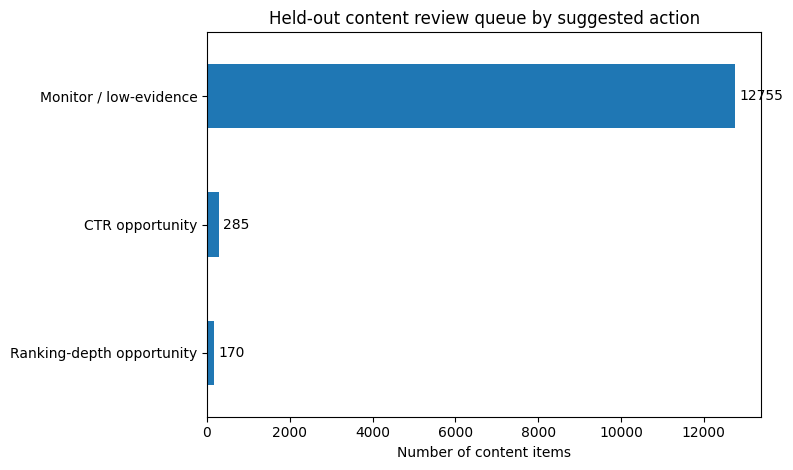

Exports written:
- work/outputs/w07_ranked_action_queue.csv
- work/outputs/w07_action_summary.csv
- work/outputs/w07_validation_receipt.json
- work/outputs/w07_playbook_manifest.json
- work/figures/w07_action_mix.png

Export safety check passed: no names/URLs/private-query columns, and human review is mandatory.


In [5]:
# Export the queue, aggregate figure, and JSON receipts for the deployed paper workflow.

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_export = queue.copy()
queue_export.to_csv(OUTPUT_DIR / "w07_ranked_action_queue.csv", index=False)
action_summary.to_csv(OUTPUT_DIR / "w07_action_summary.csv")

with open(OUTPUT_DIR / "w07_validation_receipt.json", "w", encoding="utf-8") as f:
    json.dump(validation_receipt, f, indent=2)

manifest = {
    "artifact": "Content Action Playbook",
    "intended_use": "Prioritize human review of held-out pages associated with the March decline proxy.",
    "unit_of_action": "content item / page",
    "ranking": "0.70 * grouped-model decline risk + 0.30 * held-out impression percentile",
    "actions": sorted(queue["recommended_action"].unique().tolist()),
    "human_review_required": True,
    "automation_boundary": "rank, explain and export only",
    "no_go": [
        "auto-publish content changes",
        "redirect/delete/noindex automatically",
        "claim causal ranking explanations",
        "act on regulated/high-stakes content without qualified review",
        "automatically retrain and replace the model",
    ],
    "limits": [
        "single March 2026 proxy window",
        "one client-grouped holdout",
        "does not observe conversions, revenue, backlinks, page age, seasonality or query intent",
        "refresh is a review hypothesis, not a proven cause",
    ],
}
with open(OUTPUT_DIR / "w07_playbook_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# Aggregate figure only: no client/page identifiers.
action_counts = queue["recommended_action"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
action_counts.plot(kind="barh", ax=ax)
ax.set_title("Held-out content review queue by suggested action")
ax.set_xlabel("Number of content items")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3)
fig.tight_layout()
fig_path = FIGURE_DIR / "w07_action_mix.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Exports written:")
for p in [
    OUTPUT_DIR / "w07_ranked_action_queue.csv",
    OUTPUT_DIR / "w07_action_summary.csv",
    OUTPUT_DIR / "w07_validation_receipt.json",
    OUTPUT_DIR / "w07_playbook_manifest.json",
    fig_path,
]:
    print("-", p)

# Final safety assertions.
assert not any(col in queue_export.columns for col in ["client_name", "url", "query"])
assert queue_export["human_review_required"].all()
print("\nExport safety check passed: no names/URLs/private-query columns, and human review is mandatory.")


## Self-check

Before I submit, I confirm each line honestly:

- [x] Every section above is filled — markdown thinking **and** executable code.
- [x] The playbook ranks actions and gives transparent reason codes.
- [x] Archetype → action mapping is explicit and practical.
- [x] The decay/refresh idea is framed as a directional review hypothesis, not a causal claim.
- [x] Intended use, limits, cost/value thinking, and no-go cases are stated.
- [x] Every queue row requires human review; irreversible content actions are not automated.
- [x] Monitoring and revalidation/retrain triggers are explicit and lightweight.
- [x] The notebook exports the ranked queue to `work/outputs/` and an aggregate reusable figure to `work/figures/`.
- [x] Metrics/monitoring receipts are exported as JSON so paper numbers can trace back to code.
- [x] No client names, URLs, or private queries are exported or displayed.
- [x] Claims use careful language: **observed, measured, directional, decision-support**.
- [ ] Run the notebook top to bottom in Colab with my private `HF_TOKEN` and confirm every output is visible.
- [ ] Confirm the queue CSV remains untracked/ignored while the figure and JSON receipts are committed according to repo policy.
- [ ] Commit the executed notebook as `work/notebooks/w07_action_playbook.ipynb` and submit the repo URL.

**Submission rule:** I will not check the final three boxes until the gated warehouse run has actually completed and the generated paper artifacts are in the correct repo locations.
